# Production Model Analysis

Recent-week analysis for the production LightGBM disruption model. The production feature set drops `origin_wx_n_reports` and `dest_wx_n_reports` because those diagnostic columns have no live forecast equivalent.

In [1]:
%matplotlib inline

from pathlib import Path
import sys

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(f"Could not find project root from {Path.cwd()}")

sys.path.insert(0, str(PROJECT_ROOT))

from src.train_production_model import LGBM_PARAMS, PRODUCTION_DROP, drop_production_features
from src.training_pipeline import (
    DEFAULT_JOINED,
    DEFAULT_SIGMAS,
    OCCASION_STEP_H,
    TRAIN_START_DEFAULT,
    WINDOW_H,
    add_long_term_trend,
    add_sampled_leads,
    add_trailing_disruption_features,
    build_test_occasions,
    inject_noise,
    per_occasion_table,
    prepare_features,
)
from src.weather_noise import WeatherNoiseInjector

The setup mirrors `src.evaluate_recent_week`: hold out the latest labelled week, inject the forecast-noise proxy, train on earlier data with a 30-day early-stopping validation window, and score 48-hour forecast occasions every 6 hours.

In [2]:
WEEK_DAYS = 7
VAL_DAYS = 30
STEP_H = OCCASION_STEP_H
NOISE_SCALE = 1.0
SEED = 42

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "production_model"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)

In [3]:
df = pd.read_parquet(DEFAULT_JOINED)
dep = pd.to_datetime(df["scheduled_dep_utc_hour"], utc=True)
df["scheduled_dep_utc_hour"] = dep
df = df.loc[(dep >= TRAIN_START_DEFAULT) & df["disrupted"].notna()].copy()

max_dep = df["scheduled_dep_utc_hour"].max()
week_start = max_dep.floor("D") - pd.Timedelta(days=WEEK_DAYS)
val_cut = week_start - pd.Timedelta(days=VAL_DAYS)
last_issue = max_dep - pd.Timedelta(hours=WINDOW_H)

train = df.loc[df["scheduled_dep_utc_hour"] < val_cut].reset_index(drop=True)
val = df.loc[
    (df["scheduled_dep_utc_hour"] >= val_cut)
    & (df["scheduled_dep_utc_hour"] < week_start)
].reset_index(drop=True)
test = df.loc[df["scheduled_dep_utc_hour"] >= week_start].reset_index(drop=True)

print(f"test week: {week_start.date()} -> {max_dep.date()}")
print(f"train={len(train):,}  val={len(val):,}  test pool={len(test):,}")

test week: 2026-02-22 -> 2026-03-01
train=1,385,281  val=25,895  test pool=7,001


In [4]:
train = add_sampled_leads(train, rng)
val = add_sampled_leads(val, rng)

train = add_long_term_trend(add_trailing_disruption_features(train, df))
val = add_long_term_trend(add_trailing_disruption_features(val, df))

noise = WeatherNoiseInjector.load(DEFAULT_SIGMAS, seed=SEED).with_scale(NOISE_SCALE)
train_n = inject_noise(train, noise)
val_n = inject_noise(val, noise)

X_train_full, cats = prepare_features(train_n)
X_val_full, _ = prepare_features(val_n, cat_categories=cats)
y_train = train_n["disrupted"].astype("int8").to_numpy()
y_val = val_n["disrupted"].astype("int8").to_numpy()

X_train = drop_production_features(X_train_full)
X_val = drop_production_features(X_val_full)

assert not any(col in X_train.columns for col in PRODUCTION_DROP)
assert not any(col in X_val.columns for col in PRODUCTION_DROP)

print(f"production features: {X_train.shape[1]}")

production features: 55


In [5]:
occ = build_test_occasions(test, week_start, last_issue, step_h=STEP_H)
if not len(occ):
    raise RuntimeError("No test occasions in the recent week")

occ = add_long_term_trend(add_trailing_disruption_features(occ, df))
occ_n = inject_noise(occ, noise)
X_test_full, _ = prepare_features(occ_n, cat_categories=cats)
X_test = drop_production_features(X_test_full)
y_test = occ_n["disrupted"].astype("int8").to_numpy()

assert not any(col in X_test.columns for col in PRODUCTION_DROP)

print(f"test flight-occasions: {len(y_test):,}")
print(f"forecast occasions: {occ_n['occasion_id'].nunique():,}")

test flight-occasions: 41,208
forecast occasions: 21


In [6]:
model = lgb.LGBMClassifier(random_state=SEED, **LGBM_PARAMS)
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(20, verbose=False)],
)

p_test = model.predict_proba(X_test)[:, 1]
occ_table = per_occasion_table(occ_n, p_test)

metrics = pd.Series(
    {
        "auc_roc": roc_auc_score(y_test, p_test),
        "auc_pr": average_precision_score(y_test, p_test),
        "brier": brier_score_loss(y_test, p_test),
        "base_rate": y_test.mean(),
        "mean_pred": p_test.mean(),
        "occasion_mae": occ_table["abs_error"].mean(),
        "occasion_bias": occ_table["signed_error"].mean(),
    },
    name="production",
)

metrics.round(4).to_frame()

,production
auc_roc,0.6606
auc_pr,0.5343
brier,0.2045
base_rate,0.3371
mean_pred,0.3060
occasion_mae,0.0343
occasion_bias,-0.0311


## Per-flight calibration

This is the production-only version of the calibration panel: one production curve, no `n_reports` comparison model.

PosixPath('artifacts/production_model/per_flight_calibration_production.png')

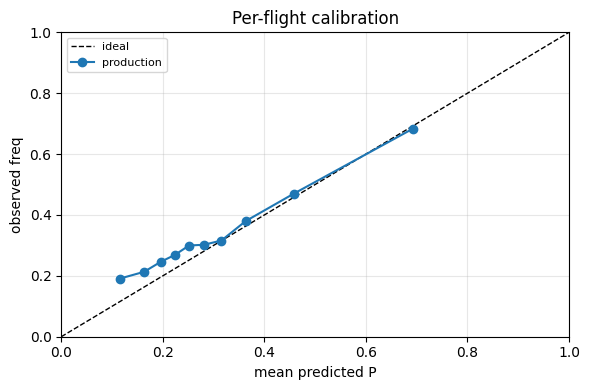

In [7]:
observed_freq, mean_pred = calibration_curve(
    y_test,
    p_test,
    n_bins=10,
    strategy="quantile",
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="ideal")
ax.plot(mean_pred, observed_freq, "o-", color="C0", label="production")
ax.set_title("Per-flight calibration")
ax.set_xlabel("mean predicted P")
ax.set_ylabel("observed freq")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()

calibration_png = ARTIFACT_DIR / "per_flight_calibration_production.png"
fig.savefig(calibration_png, dpi=140, bbox_inches="tight")
calibration_png.relative_to(PROJECT_ROOT)

## Counterfactual airline effect

This plot is a partial-dependence style check for `reporting_airline`: for every held-out flight occasion, keep route, weather, schedule, lead time, and trailing airport state fixed, then swap only the airline code and rescore. The spread shows heterogeneity across the same flight mix, not the realised risk of each airline's actual schedule.

,airline,name,actual_rows,mean_pred,delta_vs_actual_mix
10,YX,Republic,4142,0.2477,-0.0583
0,UA,United,10638,0.2809,-0.0251
9,MQ,Envoy,8319,0.2905,-0.0155
3,DL,Delta,837,0.3045,-0.0015
7,B6,JetBlue,114,0.3241,0.0180
2,AA,American,7158,0.3370,0.0309
8,OO,SkyWest,7750,0.3475,0.0414
1,WN,Southwest,390,0.3481,0.0421
5,AS,Alaska,273,0.3633,0.0573
4,NK,Spirit,649,0.3693,0.0633


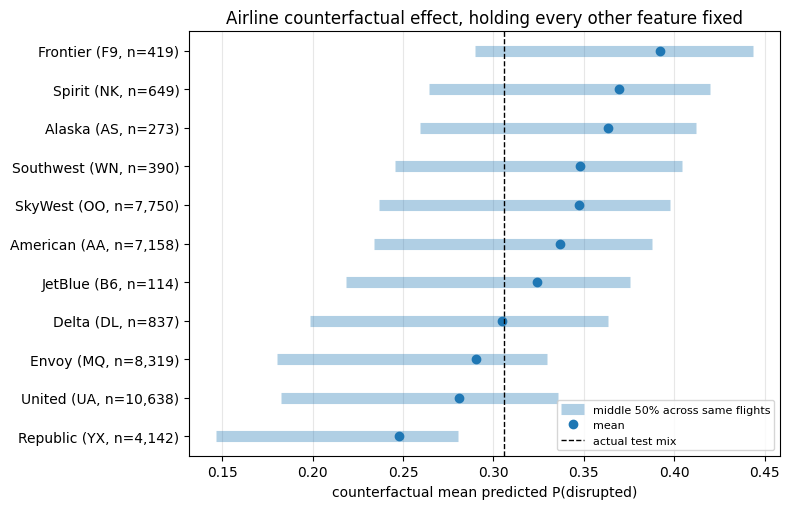

In [8]:
AIRLINE_NAMES = {
    "UA": "United",
    "WN": "Southwest",
    "AA": "American",
    "DL": "Delta",
    "NK": "Spirit",
    "AS": "Alaska",
    "F9": "Frontier",
    "B6": "JetBlue",
    "OO": "SkyWest",
    "MQ": "Envoy",
    "YX": "Republic",
}

available_airlines = set(map(str, cats["reporting_airline"]))
airline_codes = [code for code in AIRLINE_NAMES if code in available_airlines]

airline_rows = []
airline_preds = {}
for code in airline_codes:
    X_cf = X_test.copy()
    X_cf["reporting_airline"] = pd.Categorical(
        [code] * len(X_cf), categories=cats["reporting_airline"]
    )
    p_cf = model.predict_proba(X_cf)[:, 1]
    airline_preds[code] = p_cf
    airline_rows.append(
        {
            "airline": code,
            "name": AIRLINE_NAMES[code],
            "actual_rows": int((occ_n["reporting_airline"].astype(str) == code).sum()),
            "mean_pred": float(p_cf.mean()),
            "delta_vs_actual_mix": float(p_cf.mean() - p_test.mean()),
            "q25": float(np.quantile(p_cf, 0.25)),
            "median": float(np.quantile(p_cf, 0.50)),
            "q75": float(np.quantile(p_cf, 0.75)),
        }
    )

airline_effect = pd.DataFrame(airline_rows).sort_values("mean_pred")
airline_effect["label"] = (
    airline_effect["name"]
    + " ("
    + airline_effect["airline"]
    + ", n="
    + airline_effect["actual_rows"].map(lambda x: f"{x:,}")
    + ")"
)

fig, ax = plt.subplots(figsize=(8, 5.2))
y = np.arange(len(airline_effect))
ax.hlines(
    y,
    airline_effect["q25"],
    airline_effect["q75"],
    color="C0",
    lw=8,
    alpha=0.35,
    label="middle 50% across same flights",
)
ax.plot(airline_effect["mean_pred"], y, "o", color="C0", label="mean")
ax.axvline(p_test.mean(), color="k", ls="--", lw=1, label="actual test mix")
ax.set_yticks(y, airline_effect["label"])
ax.set_xlabel("counterfactual mean predicted P(disrupted)")
ax.set_title("Airline counterfactual effect, holding every other feature fixed")
ax.grid(axis="x", alpha=0.3)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()

airline_png = ARTIFACT_DIR / "airline_counterfactual_effect.png"
fig.savefig(airline_png, dpi=140, bbox_inches="tight")
airline_effect[["airline", "name", "actual_rows", "mean_pred", "delta_vs_actual_mix"]].round(4)

## Lead-time reliability

A production model is only useful if its 6-hour refresh forecasts are stable across the 48-hour horizon. This bins each flight occasion by departure lead time and compares the average predicted risk to the realised disruption rate.

,lead_bin,n,observed_rate,predicted_rate,lead_mid_h,signed_error
0,"[0, 6)",5132,0.3895,0.3552,3.0,-0.0343
1,"[6, 12)",4924,0.3672,0.3422,9.0,-0.0250
2,"[12, 18)",5303,0.3656,0.3283,15.0,-0.0373
3,"[18, 24)",5278,0.3477,0.3102,21.0,-0.0375
4,"[24, 30)",5185,0.3323,0.2953,27.0,-0.0370
5,"[30, 36)",4939,0.3094,0.2793,33.0,-0.0301
6,"[36, 42)",5269,0.3014,0.2725,39.0,-0.0289
7,"[42, 48)",5178,0.2839,0.2661,45.0,-0.0178


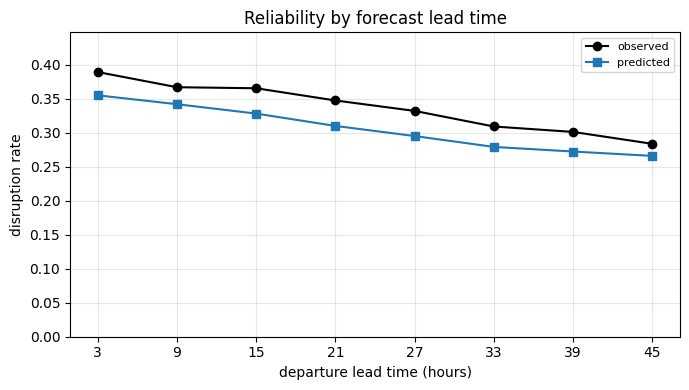

In [9]:
lead_eval = pd.DataFrame(
    {
        "lead_origin_h": occ_n["lead_origin_h"].to_numpy(),
        "y": y_test,
        "p": p_test,
    }
)
lead_eval["lead_bin"] = pd.cut(
    lead_eval["lead_origin_h"],
    bins=np.arange(0, WINDOW_H + 6, 6),
    include_lowest=True,
    right=False,
)
lead_summary = (
    lead_eval.groupby("lead_bin", observed=True)
    .agg(n=("y", "size"), observed_rate=("y", "mean"), predicted_rate=("p", "mean"))
    .reset_index()
)
lead_summary["lead_mid_h"] = lead_summary["lead_bin"].map(lambda x: x.left + (x.right - x.left) / 2)
lead_summary["signed_error"] = lead_summary["predicted_rate"] - lead_summary["observed_rate"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lead_summary["lead_mid_h"], lead_summary["observed_rate"], "o-", color="k", label="observed")
ax.plot(lead_summary["lead_mid_h"], lead_summary["predicted_rate"], "s-", color="C0", label="predicted")
ax.set_xlabel("departure lead time (hours)")
ax.set_ylabel("disruption rate")
ax.set_title("Reliability by forecast lead time")
ax.set_xticks(np.arange(3, WINDOW_H, 6))
ax.set_ylim(0, max(lead_summary[["observed_rate", "predicted_rate"]].max()) * 1.15)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()

lead_png = ARTIFACT_DIR / "lead_time_reliability.png"
fig.savefig(lead_png, dpi=140, bbox_inches="tight")
lead_summary.round(4)

## Production feature importance

LightGBM gain importance is not causal, but it is a good audit view for what the production model is using after `n_reports` is removed.

,feature,gain,split,group
27,origin_wx_p01i,356264.00,267,weather
53,dest,341401.42,4414,categorical
0,crs_dep_time,285291.33,644,schedule/time
51,days_since_2021,230308.40,1896,schedule/time
48,trailing_disruption_rate_24h,216937.60,250,airport state
52,reporting_airline,175715.33,760,categorical
50,trailing_disruption_rate_168h,113620.94,601,airport state
49,trailing_disruption_rate_72h,97332.13,390,airport state
6,day_of_week,77956.97,583,schedule/time
5,day_of_month,77471.90,840,schedule/time


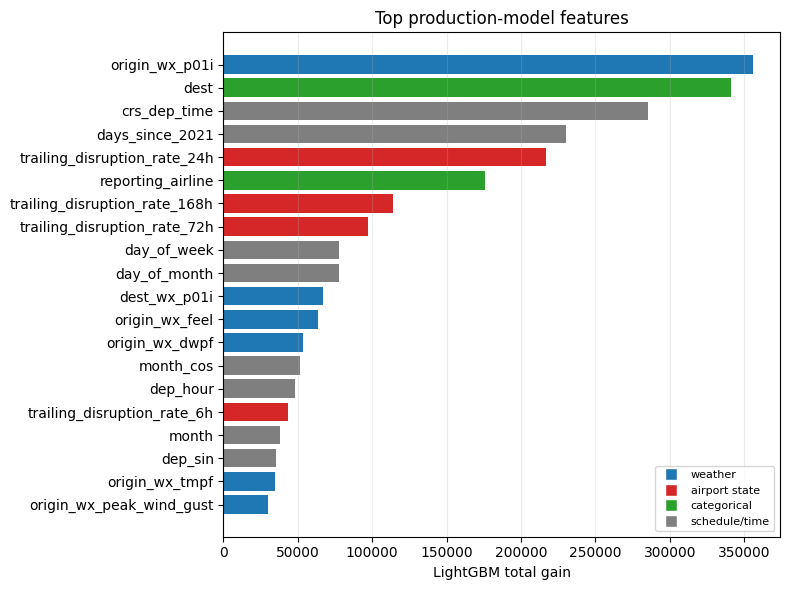

In [10]:
def feature_group(feature: str) -> str:
    if feature.startswith("origin_wx_") or feature.startswith("dest_wx_"):
        return "weather"
    if feature.startswith("trailing_disruption_rate"):
        return "airport state"
    if feature in {"reporting_airline", "dest", "dest_state"}:
        return "categorical"
    if feature in {"lead_origin_h", "lead_dest_h"}:
        return "lead time"
    return "schedule/time"

importance = pd.DataFrame(
    {
        "feature": X_train.columns,
        "gain": model.booster_.feature_importance(importance_type="gain"),
        "split": model.booster_.feature_importance(importance_type="split"),
    }
)
importance["group"] = importance["feature"].map(feature_group)
importance = importance.sort_values("gain", ascending=False)
top_importance = importance.head(20).sort_values("gain")

palette = {
    "weather": "#1f77b4",
    "airport state": "#d62728",
    "categorical": "#2ca02c",
    "lead time": "#9467bd",
    "schedule/time": "#7f7f7f",
}

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    top_importance["feature"],
    top_importance["gain"],
    color=top_importance["group"].map(palette),
)
ax.set_xlabel("LightGBM total gain")
ax.set_title("Top production-model features")
ax.grid(axis="x", alpha=0.25)

handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=color, markersize=9, label=group)
    for group, color in palette.items()
    if group in set(top_importance["group"])
]
ax.legend(handles=handles, fontsize=8, loc="lower right")
fig.tight_layout()

importance_png = ARTIFACT_DIR / "feature_importance_production.png"
fig.savefig(importance_png, dpi=140, bbox_inches="tight")
importance.head(20).round(2)